# 🛍️ Analisis Sentimen Ulasan Aplikasi Shopee
**Platform Sumber Data:** Google Play Store (com.shopee.id)  
**Bahasa:** Indonesia  
**Kelas Sentimen:** Negatif (0) | Netral (1) | Positif (2)

---
## 📋 Daftar Skema Pelatihan
| Skema | Algoritma | Ekstraksi Fitur | Split Data |
|-------|-----------|-----------------|------------|
| 1 | LSTM (Deep Learning) | Word Embedding (Keras) | 80/20 |
| 2 | IndoBERT (Transformers) | BERT Tokenizer | 80/20 |
| 3 | SVM (Baseline) | TF-IDF | 70/30 |


## 0. Instalasi Library


In [19]:
!pip install -q google-play-scraper==1.2.7
!pip install -q Sastrawi==1.0.1
!pip install -q gensim==4.3.2
!pip install -q wordcloud
!pip install -q 'transformers>=4.35.0' sentencepiece
!pip install -q 'nltk>=3.8'

In [20]:
!python scraping.py

[INFO] Mulai scraping ulasan 'com.shopee.id'
[INFO] Target: 10,000 ulasan

  Batch   1 | Terkumpul:    200 ulasan | Token: ada
  Batch   2 | Terkumpul:    400 ulasan | Token: ada
  Batch   3 | Terkumpul:    600 ulasan | Token: ada
  Batch   4 | Terkumpul:    800 ulasan | Token: ada
  Batch   5 | Terkumpul:  1,000 ulasan | Token: ada
  Batch   6 | Terkumpul:  1,200 ulasan | Token: ada
  Batch   7 | Terkumpul:  1,400 ulasan | Token: ada
  Batch   8 | Terkumpul:  1,600 ulasan | Token: ada
  Batch   9 | Terkumpul:  1,800 ulasan | Token: ada
  Batch  10 | Terkumpul:  2,000 ulasan | Token: ada
  Batch  11 | Terkumpul:  2,200 ulasan | Token: ada
  Batch  12 | Terkumpul:  2,400 ulasan | Token: ada
  Batch  13 | Terkumpul:  2,600 ulasan | Token: ada
  Batch  14 | Terkumpul:  2,800 ulasan | Token: ada
  Batch  15 | Terkumpul:  3,000 ulasan | Token: ada
  Batch  16 | Terkumpul:  3,200 ulasan | Token: ada
  Batch  17 | Terkumpul:  3,400 ulasan | Token: ada
  Batch  18 | Terkumpul:  3,600 ulasan | 

## 1. Import Library

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, os, warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder

# Deep Learning
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Embedding, LSTM, Dense, Dropout,
                                      Bidirectional, GlobalMaxPooling1D)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

# Transformers (IndoBERT)
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           TrainingArguments, Trainer)
import torch
from torch.utils.data import Dataset

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

print('✅ Semua library berhasil diimport')
print(f'TensorFlow version: {tf.__version__}')
print(f'PyTorch version: {torch.__version__}')
print(f'GPU tersedia: {tf.config.list_physical_devices("GPU")}')

✅ Semua library berhasil diimport
TensorFlow version: 2.19.0
PyTorch version: 2.10.0+cu128
GPU tersedia: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Load Dataset

In [22]:
df = pd.read_csv('shopee_reviews.csv')
print(f'Shape dataset: {df.shape}')
print(f'Kolom: {list(df.columns)}')
df.head()

Shape dataset: (7933, 9)
Kolom: ['review_id', 'username', 'rating', 'ulasan', 'tanggal', 'thumbs_up', 'versi_app', 'sentimen', 'label']


,review_id,username,rating,ulasan,tanggal,thumbs_up,versi_app,sentimen,label
0,f2f70da8-254e-4a72-a341-174662b933e3,Rizalul Faqih,2,untuk menonaktifkan fitur face id saat pembaya...,2026-04-14 10:36:01,0,3.71.31,negatif,0
1,b430257e-4f40-4e46-ad27-2b6f0cf4801c,Mail Moha,5,bagus,2026-04-14 10:35:42,0,3.70.28,positif,2
2,0f63b74c-bb19-48a4-89d8-19ecc139f471,Asep Syaipudin,5,sangat membantu,2026-04-14 10:35:39,0,NaN,positif,2
3,61fe0618-9f59-4374-a9a4-2fd049a87f44,Akhmad Faozan,5,oke oke,2026-04-14 10:34:40,0,3.71.26,positif,2
4,295e672c-abb6-41c9-b9d9-c2a16444e5cb,Annisa Shabrina,5,bagus banget aplikasi nya banyak voucher pula ...,2026-04-14 10:34:37,0,3.69.36,positif,2


In [23]:
# Info dataset
print('=== INFO DATASET ===')
print(df.info())
print('\n=== MISSING VALUES ===')
print(df.isnull().sum())
print('\n=== DISTRIBUSI SENTIMEN ===')
print(df['sentimen'].value_counts())

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7933 entries, 0 to 7932
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review_id  7933 non-null   object
 1   username   7933 non-null   object
 2   rating     7933 non-null   int64 
 3   ulasan     7933 non-null   object
 4   tanggal    7933 non-null   object
 5   thumbs_up  7933 non-null   int64 
 6   versi_app  6151 non-null   object
 7   sentimen   7933 non-null   object
 8   label      7933 non-null   int64 
dtypes: int64(3), object(6)
memory usage: 557.9+ KB
None

=== MISSING VALUES ===
review_id       0
username        0
rating          0
ulasan          0
tanggal         0
thumbs_up       0
versi_app    1782
sentimen        0
label           0
dtype: int64

=== DISTRIBUSI SENTIMEN ===
sentimen
positif    5262
negatif    2336
netral      335
Name: count, dtype: int64


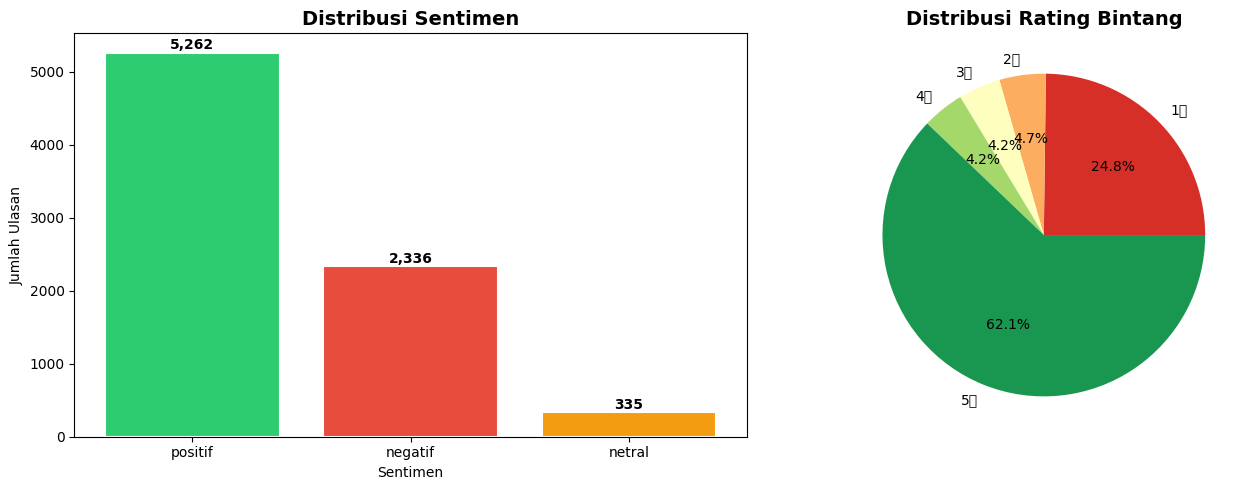

✅ Visualisasi distribusi sentimen tersimpan


In [24]:
# Visualisasi distribusi sentimen
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart sentimen
color_map = {'positif': '#2ecc71', 'netral': '#f39c12', 'negatif': '#e74c3c'}
counts = df['sentimen'].value_counts()
bars = axes[0].bar(counts.index, counts.values,
                   color=[color_map[s] for s in counts.index], edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribusi Sentimen', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentimen')
axes[0].set_ylabel('Jumlah Ulasan')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', fontweight='bold')

# Pie chart rating
rating_counts = df['rating'].value_counts().sort_index()
axes[1].pie(rating_counts.values, labels=[f'{i}⭐' for i in rating_counts.index],
            autopct='%1.1f%%', colors=plt.cm.RdYlGn(np.linspace(0.1, 0.9, 5)))
axes[1].set_title('Distribusi Rating Bintang', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('distribusi_sentimen.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualisasi distribusi sentimen tersimpan')

## 3. Preprocessing Teks

In [25]:
# Kamus normalisasi kata slang Indonesia
slang_dict = {
    'gak': 'tidak', 'ga': 'tidak', 'nggak': 'tidak', 'ngga': 'tidak',
    'tdk': 'tidak', 'tdk': 'tidak', 'krn': 'karena', 'karna': 'karena',
    'udah': 'sudah', 'udh': 'sudah', 'sdh': 'sudah', 'dah': 'sudah',
    'yg': 'yang', 'dgn': 'dengan', 'utk': 'untuk', 'dr': 'dari',
    'hrs': 'harus', 'blm': 'belum', 'bs': 'bisa', 'bgt': 'banget',
    'banget': 'sekali', 'bgs': 'bagus', 'oke': 'baik', 'ok': 'baik',
    'mantap': 'bagus', 'mantul': 'bagus', 'keren': 'bagus',
    'jelek': 'buruk', 'ancur': 'buruk', 'parah': 'buruk',
    'lama': 'lambat', 'lemot': 'lambat', 'slow': 'lambat',
    'mahal': 'mahal', 'murah': 'murah', 'gratif': 'gratis',
    'ongkir': 'ongkos kirim', 'cod': 'bayar di tempat',
    'seller': 'penjual', 'buyer': 'pembeli', 'shop': 'toko',
    'update': 'perbarui', 'bug': 'kesalahan', 'error': 'kesalahan',
    'loading': 'memuat', 'crash': 'berhenti tiba-tiba',
    'pnj': 'panjang', 'msh': 'masih', 'jg': 'juga', 'jd': 'jadi',
    'dl': 'dulu', 'dlu': 'dulu', 'sy': 'saya', 'aq': 'saya',
    'gw': 'saya', 'gue': 'saya', 'lo': 'kamu', 'lu': 'kamu',
    'tp': 'tapi', 'tapi': 'tetapi', 'tp': 'tetapi',
    'apl': 'aplikasi', 'app': 'aplikasi', 'apk': 'aplikasi',
    'lg': 'lagi', 'lagi': 'lagi', 'aj': 'saja', 'aja': 'saja',
    'mau': 'ingin', 'mo': 'ingin',
}

# Inisiasi stemmer dan stopwords
factory = StemmerFactory()
stemmer = factory.create_stemmer()
stop_words = set(stopwords.words('indonesian'))
# Tambah stopwords kustom
custom_stop = {'shopee', 'aplikasi', 'app', 'apk', 'ya', 'yah', 'deh',
                'loh', 'nih', 'sih', 'dong', 'wah', 'hah', 'hmm'}
stop_words.update(custom_stop)


def preprocess_text(text: str, use_stemming: bool = True) -> str:
    """
    Pipeline preprocessing teks Bahasa Indonesia:
    1. Lowercase
    2. Hapus URL, mention, hashtag
    3. Hapus angka dan tanda baca
    4. Normalisasi kata slang
    5. Tokenisasi
    6. Hapus stopwords
    7. Stemming (opsional)
    """
    if not isinstance(text, str):
        return ''

    # 1. Lowercase
    text = text.lower()

    # 2. Hapus URL, mention, hashtag, emoji
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)  # non-ASCII (emoji)

    # 3. Hapus angka dan tanda baca
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 4. Normalisasi slang
    words = text.split()
    words = [slang_dict.get(w, w) for w in words]
    text = ' '.join(words)

    # 5. Tokenisasi
    tokens = word_tokenize(text)

    # 6. Hapus stopwords (min 2 karakter)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]

    # 7. Stemming
    if use_stemming:
        tokens = [stemmer.stem(t) for t in tokens]

    return ' '.join(tokens)


print('Memulai preprocessing (Sastrawi stemmer mungkin memerlukan beberapa menit)...')
from tqdm import tqdm
tqdm.pandas()

df['teks_bersih'] = df['ulasan'].progress_apply(lambda x: preprocess_text(x, use_stemming=True))

# Hapus teks yang kosong setelah preprocessing
df = df[df['teks_bersih'].str.strip() != ''].reset_index(drop=True)

print(f'\n✅ Preprocessing selesai!')
print(f'Jumlah data: {len(df):,}')
print('\nContoh hasil preprocessing:')
sample = df[['ulasan', 'teks_bersih', 'sentimen']].sample(5, random_state=42)
for _, row in sample.iterrows():
    print(f'  Asli   : {row["ulasan"][:80]}')
    print(f'  Bersih : {row["teks_bersih"][:80]}')
    print(f'  Label  : {row["sentimen"]}')
    print()

Memulai preprocessing (Sastrawi stemmer mungkin memerlukan beberapa menit)...


100%|██████████| 7933/7933 [15:08<00:00,  8.73it/s]


✅ Preprocessing selesai!
Jumlah data: 7,788

Contoh hasil preprocessing:
  Asli   : transaksi pembelian mudah,jenis barang sesuai
  Bersih : transaksi beli mudahjenis barang sesuai
  Label  : positif

  Asli   : trima kasih shopee..sangat membantu & mempermudah cari barang
  Bersih : trima kasih shopeesangat bantu mudah cari barang
  Label  : positif

  Asli   : jelek bgt
  Bersih : buruk banget
  Label  : negatif

  Asli   : untuk kenyamanan jual beli oke, cuma sebelnya setelah di upgrade apk nya, akun s
  Bersih : nyaman jual beli sebel upgrade nya akun hilang
  Label  : netral

  Asli   : cs GK bsa kasih solusi sama sekali terkait kendala paket
  Bersih : cs gk bsa kasih solusi kait kendala paket
  Label  : negatif



In [26]:
# Simpan dataset yang sudah dipreprocessing
df.to_csv('shopee_reviews_preprocessed.csv', index=False, encoding='utf-8-sig')
print('✅ Dataset preprocessed tersimpan: shopee_reviews_preprocessed.csv')

# Encode label
label_map = {'negatif': 0, 'netral': 1, 'positif': 2}
df['label_enc'] = df['sentimen'].map(label_map)
print(f'Label mapping: {label_map}')

✅ Dataset preprocessed tersimpan: shopee_reviews_preprocessed.csv
Label mapping: {'negatif': 0, 'netral': 1, 'positif': 2}


---
## 4. Skema 1 — LSTM (Deep Learning) + Word Embedding | Split 80/20

In [27]:
print('=' * 60)
print('  SKEMA 1: Bidirectional LSTM + Word Embedding')
print('  Split: 80% Training / 20% Testing')
print('=' * 60)

# ── Parameter ──────────────────────────────────────────────
MAX_WORDS   = 20_000   # Ukuran kosakata
MAX_LEN     = 100      # Panjang maksimal sequence
EMBED_DIM   = 128      # Dimensi embedding
LSTM_UNITS  = 128      # Unit LSTM
BATCH_SIZE  = 128
EPOCHS      = 20
NUM_CLASSES = 3

# ── Persiapan Data ─────────────────────────────────────────
X = df['teks_bersih'].values
y = df['label_enc'].values

X_train_s1, X_test_s1, y_train_s1, y_test_s1 = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train_s1):,} | Test: {len(X_test_s1):,}')

# ── Tokenisasi ─────────────────────────────────────────────
tokenizer_lstm = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer_lstm.fit_on_texts(X_train_s1)

X_train_seq = pad_sequences(tokenizer_lstm.texts_to_sequences(X_train_s1),
                             maxlen=MAX_LEN, padding='post', truncating='post')
X_test_seq  = pad_sequences(tokenizer_lstm.texts_to_sequences(X_test_s1),
                             maxlen=MAX_LEN, padding='post', truncating='post')

# One-hot encoding label
y_train_cat = to_categorical(y_train_s1, NUM_CLASSES)
y_test_cat  = to_categorical(y_test_s1,  NUM_CLASSES)

print(f'Shape X_train: {X_train_seq.shape}')
print(f'Shape X_test : {X_test_seq.shape}')

  SKEMA 1: Bidirectional LSTM + Word Embedding
  Split: 80% Training / 20% Testing
Train: 6,230 | Test: 1,558
Shape X_train: (6230, 100)
Shape X_test : (1558, 100)


In [28]:
# ── Bangun Model LSTM ──────────────────────────────────────
tf.random.set_seed(42)

model_lstm = Sequential([
    Embedding(MAX_WORDS, EMBED_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(LSTM_UNITS, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(NUM_CLASSES, activation='softmax')
], name='BiLSTM_Sentiment')

model_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_lstm.summary()

Model: "BiLSTM_Sentiment"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [29]:
# ── Training ───────────────────────────────────────────────
callbacks_lstm = [
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True),
    ModelCheckpoint('model_lstm_best.h5', monitor='val_accuracy',
                    save_best_only=True, verbose=0)
]

history_lstm = model_lstm.fit(
    X_train_seq, y_train_cat,
    validation_data=(X_test_seq, y_test_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_lstm,
    verbose=1
)

Epoch 1/20
48/49 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6866 - loss: 0.7754

49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.7448 - loss: 0.6589 - val_accuracy: 0.8370 - val_loss: 0.4725
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8489 - loss: 0.4415

49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.8618 - loss: 0.4099 - val_accuracy: 0.8466 - val_loss: 0.4410
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8940 - loss: 0.3350

49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.8974 - loss: 0.3247 - val_accuracy: 0.8537 - val_loss: 0.4463
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9122 - loss: 0.2736 - val_accuracy: 0.8472 - val_loss: 0.4511
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9254 - loss: 0.2283 - val_accuracy: 0.8338 - val_loss: 0.5075
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9323 - loss: 0.2026 - val_accuracy: 0.8241 - val_loss: 0.6183
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9360 - loss: 0.1918 - val_accuracy: 0.8241 - val_loss: 0.5882



  HASIL EVALUASI SKEMA 1 — BiLSTM
  Akurasi Training : 0.9181 (91.81%)
  Akurasi Testing  : 0.8537 (85.37%)

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.74      0.85      0.79       465
      Netral       0.00      0.00      0.00        66
     Positif       0.91      0.91      0.91      1027

    accuracy                           0.85      1558
   macro avg       0.55      0.59      0.57      1558
weighted avg       0.82      0.85      0.84      1558



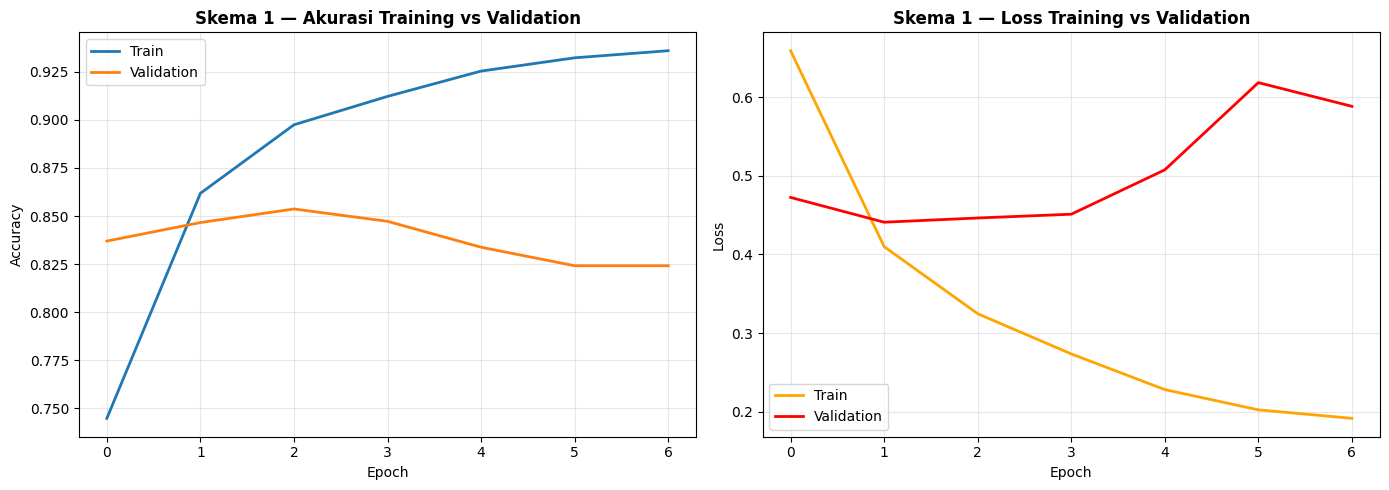

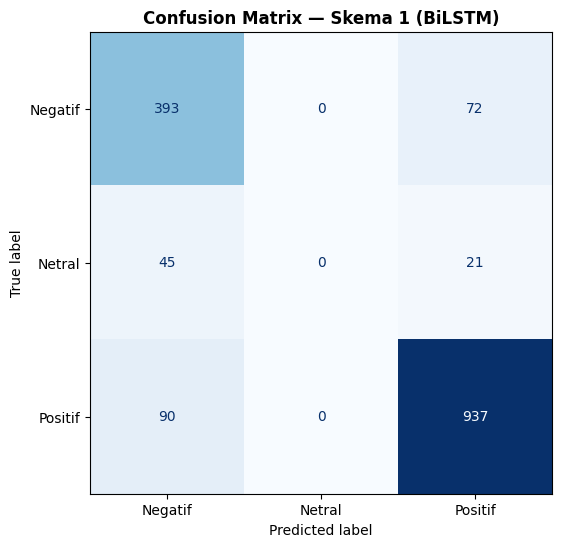

In [30]:
# ── Evaluasi Skema 1 ───────────────────────────────────────
train_loss_s1, train_acc_s1 = model_lstm.evaluate(X_train_seq, y_train_cat, verbose=0)
test_loss_s1,  test_acc_s1  = model_lstm.evaluate(X_test_seq,  y_test_cat,  verbose=0)

y_pred_s1 = np.argmax(model_lstm.predict(X_test_seq, verbose=0), axis=1)

print('\n' + '='*60)
print('  HASIL EVALUASI SKEMA 1 — BiLSTM')
print('='*60)
print(f'  Akurasi Training : {train_acc_s1:.4f} ({train_acc_s1*100:.2f}%)')
print(f'  Akurasi Testing  : {test_acc_s1:.4f} ({test_acc_s1*100:.2f}%)')
print('\nClassification Report:')
print(classification_report(y_test_s1, y_pred_s1,
                             target_names=['Negatif', 'Netral', 'Positif']))

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_lstm.history['accuracy'],    label='Train', linewidth=2)
axes[0].plot(history_lstm.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Skema 1 — Akurasi Training vs Validation', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_lstm.history['loss'],    label='Train', linewidth=2, color='orange')
axes[1].plot(history_lstm.history['val_loss'], label='Validation', linewidth=2, color='red')
axes[1].set_title('Skema 1 — Loss Training vs Validation', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('skema1_history.png', dpi=150, bbox_inches='tight')
plt.show()

# Confusion Matrix
cm_s1 = confusion_matrix(y_test_s1, y_pred_s1)
disp  = ConfusionMatrixDisplay(cm_s1, display_labels=['Negatif', 'Netral', 'Positif'])
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Skema 1 (BiLSTM)', fontweight='bold')
plt.savefig('skema1_cm.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Skema 2 — IndoBERT (Transformers) | Split 80/20

In [31]:
print('=' * 60)
print('  SKEMA 2: IndoBERT (indobenchmark/indobert-base-p1)')
print('  Split: 80% Training / 20% Testing')
print('=' * 60)

MODEL_NAME = 'indobenchmark/indobert-base-p1'
MAX_LEN_BERT = 128
BERT_BATCH   = 16
BERT_EPOCHS  = 5

# Gunakan teks TANPA stemming untuk BERT (BERT sudah paham konteks)
df['teks_nostem'] = df['ulasan'].apply(lambda x: preprocess_text(x, use_stemming=False))

X_bert = df['teks_nostem'].values
y_bert = df['label_enc'].values

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_bert, y_bert, test_size=0.2, random_state=42, stratify=y_bert
)
print(f'Train: {len(X_train_b):,} | Test: {len(X_test_b):,}')

# Load tokenizer IndoBERT
print(f'\nMemuat tokenizer IndoBERT: {MODEL_NAME}')
bert_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

  SKEMA 2: IndoBERT (indobenchmark/indobert-base-p1)
  Split: 80% Training / 20% Testing
Train: 6,230 | Test: 1,558

Memuat tokenizer IndoBERT: indobenchmark/indobert-base-p1


In [32]:
# ── Dataset Class untuk PyTorch ────────────────────────────
class ShopeeDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'     : encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels'        : torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset_bert = ShopeeDataset(X_train_b, y_train_b, bert_tokenizer, MAX_LEN_BERT)
test_dataset_bert  = ShopeeDataset(X_test_b,  y_test_b,  bert_tokenizer, MAX_LEN_BERT)
print(f'Dataset siap: {len(train_dataset_bert)} train, {len(test_dataset_bert)} test')

Dataset siap: 6230 train, 1558 test


In [33]:
# ── Load Model IndoBERT ────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

model_bert = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3
).to(device)

# ── Training Arguments ─────────────────────────────────────
training_args = TrainingArguments(
    output_dir              = './results_bert',
    num_train_epochs        = BERT_EPOCHS,
    per_device_train_batch_size = BERT_BATCH,
    per_device_eval_batch_size  = BERT_BATCH,
    warmup_steps            = 200,
    weight_decay            = 0.01,
    learning_rate           = 2e-5,
    eval_strategy     = 'epoch',
    save_strategy           = 'epoch',
    load_best_model_at_end  = True,
    metric_for_best_model   = 'eval_accuracy',
    logging_dir             = './logs_bert',
    logging_steps           = 100,
    fp16                    = torch.cuda.is_available(),
    report_to               = 'none'
)

# ── Metrics Function ───────────────────────────────────────
from sklearn.metrics import accuracy_score as acc_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {'accuracy': acc_score(labels, preds)}

# ── Trainer ────────────────────────────────────────────────
trainer = Trainer(
    model           = model_bert,
    args            = training_args,
    train_dataset   = train_dataset_bert,
    eval_dataset    = test_dataset_bert,
    compute_metrics = compute_metrics,
)

print('\nMemulai training IndoBERT...')
trainer.train()

Device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.



Memulai training IndoBERT...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.461637,0.404488,0.869705
2,0.369410,0.429901,0.869063
3,0.254068,0.487235,0.862644
4,0.148766,0.560079,0.854942
5,0.104196,0.650473,0.851091


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1950, training_loss=0.27146322103647086, metrics={'train_runtime': 447.1382, 'train_samples_per_second': 69.665, 'train_steps_per_second': 4.361, 'total_flos': 2048995740556800.0, 'train_loss': 0.27146322103647086, 'epoch': 5.0})


  HASIL EVALUASI SKEMA 2 — IndoBERT
  Akurasi Training : 0.8888 (88.88%)
  Akurasi Testing  : 0.8697 (86.97%)

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.78      0.84      0.81       465
      Netral       0.00      0.00      0.00        66
     Positif       0.91      0.94      0.92      1027

    accuracy                           0.87      1558
   macro avg       0.56      0.59      0.58      1558
weighted avg       0.83      0.87      0.85      1558



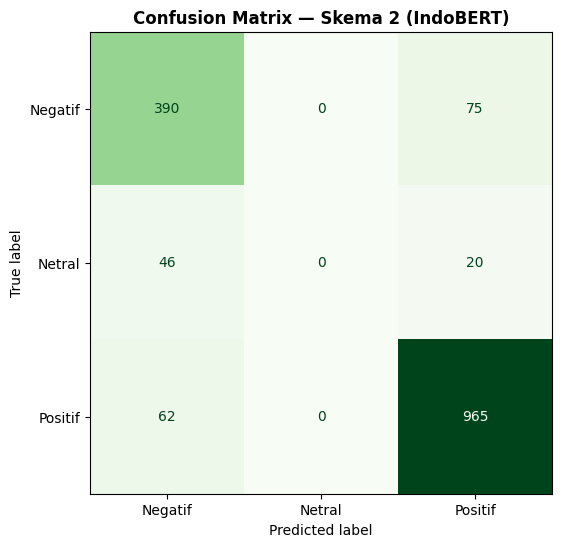

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Model IndoBERT tersimpan di: ./model_indobert_saved


In [34]:
# ── Evaluasi Skema 2 ───────────────────────────────────────
# Training accuracy
train_results_b = trainer.evaluate(train_dataset_bert)
test_results_b  = trainer.evaluate(test_dataset_bert)

print('\n' + '='*60)
print('  HASIL EVALUASI SKEMA 2 — IndoBERT')
print('='*60)
print(f'  Akurasi Training : {train_results_b["eval_accuracy"]:.4f} '
      f'({train_results_b["eval_accuracy"]*100:.2f}%)')
print(f'  Akurasi Testing  : {test_results_b["eval_accuracy"]:.4f} '
      f'({test_results_b["eval_accuracy"]*100:.2f}%)')

# Classification Report
pred_outputs = trainer.predict(test_dataset_bert)
y_pred_b     = np.argmax(pred_outputs.predictions, axis=1)

print('\nClassification Report:')
print(classification_report(y_test_b, y_pred_b,
                             target_names=['Negatif', 'Netral', 'Positif']))

# Confusion Matrix
cm_b = confusion_matrix(y_test_b, y_pred_b)
disp = ConfusionMatrixDisplay(cm_b, display_labels=['Negatif', 'Netral', 'Positif'])
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title('Confusion Matrix — Skema 2 (IndoBERT)', fontweight='bold')
plt.savefig('skema2_cm.png', dpi=150, bbox_inches='tight')
plt.show()

# Simpan model
model_bert.save_pretrained('./model_indobert_saved')
bert_tokenizer.save_pretrained('./model_indobert_saved')
print('\n✅ Model IndoBERT tersimpan di: ./model_indobert_saved')

---
## 6. Skema 3 — SVM (Baseline) + TF-IDF | Split 70/30

  SKEMA 3: LinearSVC (SVM) + TF-IDF
  Split: 70% Training / 30% Testing
Train: 5,451 | Test: 2,337
Shape TF-IDF train: (5451, 5520)
Shape TF-IDF test : (2337, 5520)

✅ SVM selesai dilatih

  HASIL EVALUASI SKEMA 3 — LinearSVM + TF-IDF
  Akurasi Training : 0.9736 (97.36%)
  Akurasi Testing  : 0.8464 (84.64%)

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.76      0.80      0.78       698
      Netral       0.00      0.00      0.00        99
     Positif       0.90      0.92      0.91      1540

    accuracy                           0.85      2337
   macro avg       0.55      0.57      0.56      2337
weighted avg       0.82      0.85      0.83      2337



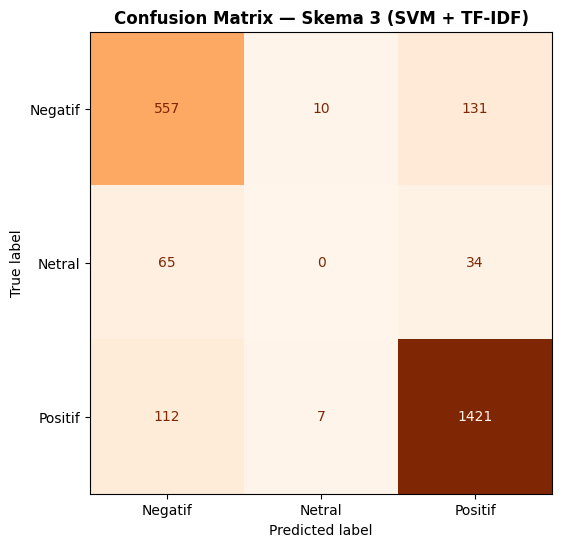


✅ Model SVM & TF-IDF tersimpan


In [35]:
print('=' * 60)
print('  SKEMA 3: LinearSVC (SVM) + TF-IDF')
print('  Split: 70% Training / 30% Testing')
print('=' * 60)

X_s3 = df['teks_bersih'].values
y_s3 = df['label_enc'].values

X_train_s3, X_test_s3, y_train_s3, y_test_s3 = train_test_split(
    X_s3, y_s3, test_size=0.3, random_state=42, stratify=y_s3
)
print(f'Train: {len(X_train_s3):,} | Test: {len(X_test_s3):,}')

# ── TF-IDF Vectorizer ──────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features = 30_000,
    ngram_range  = (1, 2),    # Unigram + Bigram
    min_df       = 2,
    sublinear_tf = True
)
X_train_tfidf = tfidf.fit_transform(X_train_s3)
X_test_tfidf  = tfidf.transform(X_test_s3)

print(f'Shape TF-IDF train: {X_train_tfidf.shape}')
print(f'Shape TF-IDF test : {X_test_tfidf.shape}')

# ── Latih Model SVM ────────────────────────────────────────
svm_model = LinearSVC(
    C=1.0, max_iter=2000, random_state=42
)
svm_model.fit(X_train_tfidf, y_train_s3)
print('\n✅ SVM selesai dilatih')

# ── Evaluasi Skema 3 ───────────────────────────────────────
train_acc_s3 = accuracy_score(y_train_s3, svm_model.predict(X_train_tfidf))
test_acc_s3  = accuracy_score(y_test_s3,  svm_model.predict(X_test_tfidf))
y_pred_s3    = svm_model.predict(X_test_tfidf)

print('\n' + '='*60)
print('  HASIL EVALUASI SKEMA 3 — LinearSVM + TF-IDF')
print('='*60)
print(f'  Akurasi Training : {train_acc_s3:.4f} ({train_acc_s3*100:.2f}%)')
print(f'  Akurasi Testing  : {test_acc_s3:.4f} ({test_acc_s3*100:.2f}%)')
print('\nClassification Report:')
print(classification_report(y_test_s3, y_pred_s3,
                             target_names=['Negatif', 'Netral', 'Positif']))

# Confusion Matrix
cm_s3 = confusion_matrix(y_test_s3, y_pred_s3)
disp  = ConfusionMatrixDisplay(cm_s3, display_labels=['Negatif', 'Netral', 'Positif'])
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title('Confusion Matrix — Skema 3 (SVM + TF-IDF)', fontweight='bold')
plt.savefig('skema3_cm.png', dpi=150, bbox_inches='tight')
plt.show()

# Simpan model SVM
import joblib
joblib.dump(svm_model, 'model_svm.pkl')
joblib.dump(tfidf,     'tfidf_vectorizer.pkl')
print('\n✅ Model SVM & TF-IDF tersimpan')

## 7. Perbandingan Hasil Ketiga Skema

  PERBANDINGAN HASIL KETIGA SKEMA PELATIHAN
               Skema             Algoritma Ekstraksi Fitur Split Data Akurasi Train Akurasi Test
    Skema 1 — BiLSTM    Bidirectional LSTM  Word Embedding      80/20        91.81%       85.37%
  Skema 2 — IndoBERT IndoBERT Transformers  BERT Tokenizer      80/20        88.88%       86.97%
Skema 3 — SVM+TF-IDF             LinearSVC   TF-IDF Bigram      70/30        97.36%       84.64%


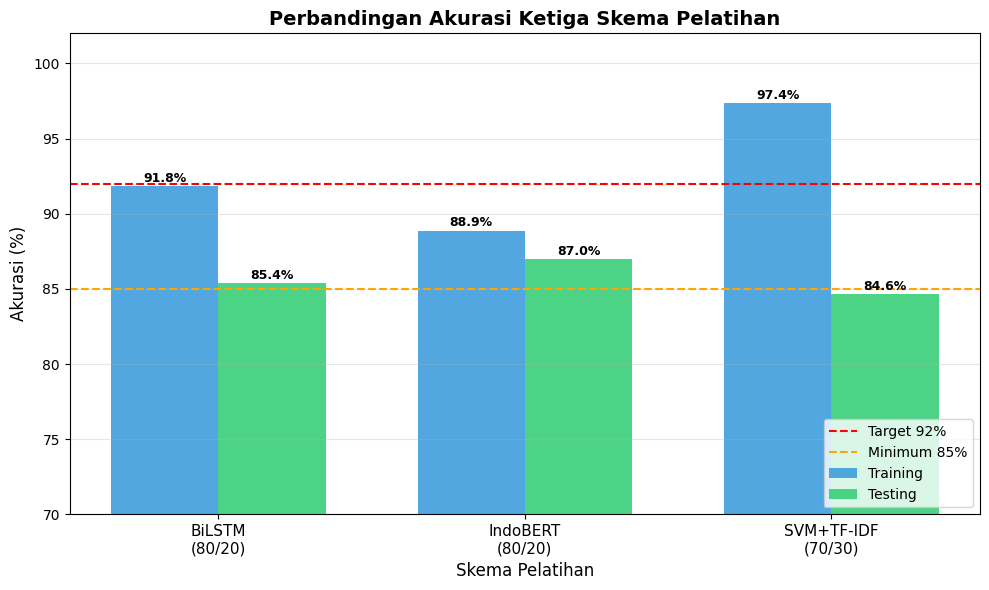

✅ Grafik perbandingan tersimpan


In [36]:
# Ringkasan hasil
results_summary = pd.DataFrame({
    'Skema'           : ['Skema 1 — BiLSTM', 'Skema 2 — IndoBERT', 'Skema 3 — SVM+TF-IDF'],
    'Algoritma'       : ['Bidirectional LSTM', 'IndoBERT Transformers', 'LinearSVC'],
    'Ekstraksi Fitur' : ['Word Embedding', 'BERT Tokenizer', 'TF-IDF Bigram'],
    'Split Data'      : ['80/20', '80/20', '70/30'],
    'Akurasi Train'   : [
        f'{train_acc_s1*100:.2f}%',
        f'{train_results_b["eval_accuracy"]*100:.2f}%',
        f'{train_acc_s3*100:.2f}%'
    ],
    'Akurasi Test'    : [
        f'{test_acc_s1*100:.2f}%',
        f'{test_results_b["eval_accuracy"]*100:.2f}%',
        f'{test_acc_s3*100:.2f}%'
    ],
})

print('='*75)
print('  PERBANDINGAN HASIL KETIGA SKEMA PELATIHAN')
print('='*75)
print(results_summary.to_string(index=False))
print('='*75)

# Visualisasi perbandingan
fig, ax = plt.subplots(figsize=(10, 6))
skema_names = ['BiLSTM\n(80/20)', 'IndoBERT\n(80/20)', 'SVM+TF-IDF\n(70/30)']
train_accs  = [train_acc_s1, train_results_b['eval_accuracy'], train_acc_s3]
test_accs   = [test_acc_s1,  test_results_b['eval_accuracy'],  test_acc_s3]

x = np.arange(len(skema_names))
w = 0.35
bars1 = ax.bar(x - w/2, [v*100 for v in train_accs], w, label='Training', color='#3498db', alpha=0.85)
bars2 = ax.bar(x + w/2, [v*100 for v in test_accs],  w, label='Testing',  color='#2ecc71', alpha=0.85)

ax.axhline(y=92, color='red',    linestyle='--', linewidth=1.5, label='Target 92%')
ax.axhline(y=85, color='orange', linestyle='--', linewidth=1.5, label='Minimum 85%')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Skema Pelatihan', fontsize=12)
ax.set_ylabel('Akurasi (%)', fontsize=12)
ax.set_title('Perbandingan Akurasi Ketiga Skema Pelatihan', fontsize=14, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(skema_names, fontsize=11)
ax.set_ylim(70, 102)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('perbandingan_skema.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik perbandingan tersimpan')

---
## 8. Inference — Prediksi Sentimen Teks Baru
> ✅ **Saran 6:** Cell ini menunjukkan output berupa kelas kategorikal (negatif / netral / positif)

In [37]:
# ── Fungsi Inference ───────────────────────────────────────
label_decode = {0: 'NEGATIF ❌', 1: 'NETRAL  ➖', 2: 'POSITIF ✅'}

def predict_lstm(text: str) -> str:
    """Prediksi sentimen menggunakan model BiLSTM."""
    clean   = preprocess_text(text, use_stemming=True)
    seq     = pad_sequences(tokenizer_lstm.texts_to_sequences([clean]),
                            maxlen=MAX_LEN, padding='post', truncating='post')
    probs   = model_lstm.predict(seq, verbose=0)[0]
    pred    = np.argmax(probs)
    return label_decode[pred], probs


def predict_indobert(text: str) -> str:
    """Prediksi sentimen menggunakan model IndoBERT."""
    model_bert.eval()
    enc = bert_tokenizer(
        text, max_length=MAX_LEN_BERT,
        padding='max_length', truncation=True, return_tensors='pt'
    )
    with torch.no_grad():
        output = model_bert(
            input_ids      = enc['input_ids'].to(device),
            attention_mask = enc['attention_mask'].to(device)
        )
    probs = torch.softmax(output.logits, dim=1).cpu().numpy()[0]
    pred  = np.argmax(probs)
    return label_decode[pred], probs


def predict_svm(text: str) -> str:
    """Prediksi sentimen menggunakan model SVM + TF-IDF."""
    clean  = preprocess_text(text, use_stemming=True)
    vec    = tfidf.transform([clean])
    pred   = svm_model.predict(vec)[0]
    return label_decode[pred]


# ── Demo Inference ─────────────────────────────────────────
test_texts = [
    "Aplikasi sangat bagus, pengiriman cepat, barang sesuai deskripsi, puas banget!",
    "Biasa aja sih, tidak ada yang spesial, pengiriman standar",
    "Barang tidak sampai, penjual tidak responsif, uang hangus! Sangat mengecewakan.",
    "Shopee semakin lambat dan sering error, tolong segera diperbaiki",
    "Harga terjangkau, banyak promo menarik, recommended!",
]

print('='*70)
print('  DEMO INFERENCE — PREDIKSI SENTIMEN')
print('='*70)

for i, text in enumerate(test_texts, 1):
    lstm_label, lstm_probs  = predict_lstm(text)
    bert_label, bert_probs  = predict_indobert(text)
    svm_label               = predict_svm(text)

    print(f'\n[{i}] Teks: "{text[:65]}..."' if len(text) > 65 else f'\n[{i}] Teks: "{text}"')
    print(f'     BiLSTM    → {lstm_label}  | Prob: {lstm_probs}')
    print(f'     IndoBERT  → {bert_label}  | Prob: {bert_probs}')
    print(f'     SVM+TFIDF → {svm_label}')

print('\n' + '='*70)
print('✅ Inference selesai!')

  DEMO INFERENCE — PREDIKSI SENTIMEN

[1] Teks: "Aplikasi sangat bagus, pengiriman cepat, barang sesuai deskripsi,..."
     BiLSTM    → POSITIF ✅  | Prob: [4.6173643e-04 8.4219070e-04 9.9869615e-01]
     IndoBERT  → POSITIF ✅  | Prob: [0.00380888 0.00601566 0.9901754 ]
     SVM+TFIDF → POSITIF ✅

[2] Teks: "Biasa aja sih, tidak ada yang spesial, pengiriman standar"
     BiLSTM    → POSITIF ✅  | Prob: [0.2392369  0.09323628 0.66752684]
     IndoBERT  → POSITIF ✅  | Prob: [0.2524983  0.14071672 0.60678494]
     SVM+TFIDF → POSITIF ✅

[3] Teks: "Barang tidak sampai, penjual tidak responsif, uang hangus! Sangat..."
     BiLSTM    → POSITIF ✅  | Prob: [0.11200745 0.07367645 0.8143161 ]
     IndoBERT  → NEGATIF ❌  | Prob: [0.7856931  0.07621501 0.13809182]
     SVM+TFIDF → POSITIF ✅

[4] Teks: "Shopee semakin lambat dan sering error, tolong segera diperbaiki"
     BiLSTM    → POSITIF ✅  | Prob: [0.30426753 0.09703512 0.59869736]
     IndoBERT  → NEGATIF ❌  | Prob: [0.4560708 0.1593161 0.3846

In [38]:
# ── Inference Interaktif ───────────────────────────────────
print('\n=== INFERENCE INTERAKTIF ===')
print('Masukkan teks ulasan Shopee untuk diprediksi sentimennya.')
print('Ketik "exit" untuk keluar.\n')

while True:
    user_input = input('\nMasukkan ulasan: ').strip()
    if user_input.lower() == 'exit':
        print('Inference selesai.')
        break
    if not user_input:
        print('⚠️  Teks tidak boleh kosong.')
        continue

    lstm_label, lstm_probs = predict_lstm(user_input)
    bert_label, bert_probs = predict_indobert(user_input)
    svm_label              = predict_svm(user_input)

    print(f'  BiLSTM   → {lstm_label}   (Neg: {lstm_probs[0]:.2f} | Net: {lstm_probs[1]:.2f} | Pos: {lstm_probs[2]:.2f})')
    print(f'  IndoBERT → {bert_label}   (Neg: {bert_probs[0]:.2f} | Net: {bert_probs[1]:.2f} | Pos: {bert_probs[2]:.2f})')
    print(f'  SVM      → {svm_label}')


=== INFERENCE INTERAKTIF ===
Masukkan teks ulasan Shopee untuk diprediksi sentimennya.
Ketik "exit" untuk keluar.


Masukkan ulasan: aplikasinya sering ngebug
  BiLSTM   → NEGATIF ❌   (Neg: 0.73 | Net: 0.12 | Pos: 0.15)
  IndoBERT → NEGATIF ❌   (Neg: 0.50 | Net: 0.16 | Pos: 0.34)
  SVM      → NEGATIF ❌

Masukkan ulasan: chatbotnya bagus
  BiLSTM   → POSITIF ✅   (Neg: 0.00 | Net: 0.01 | Pos: 0.99)
  IndoBERT → POSITIF ✅   (Neg: 0.00 | Net: 0.00 | Pos: 0.99)
  SVM      → POSITIF ✅

Masukkan ulasan: exit
Inference selesai.
